In [31]:
import numpy as np
import matplotlib.pyplot as plt
import time 
import random
import math

Matrix #   | Size (N)   | Naive Time (s)     | NumPy Time (s)    
-----------------------------------------------------------------
#1        | 3          | 0.000022           | 0.000059          
#2        | 6          | 0.000058           | 0.000014          
#3        | 12         | 0.000346           | 0.000013          
#4        | 24         | 0.002547           | 0.000055          
#5        | 48         | 0.035027           | 0.000121          
#6        | 96         | 0.155826           | 0.000322          
#7        | 192        | 1.219795           | 0.004689          
#8        | 384        | 10.322571          | 0.005213          


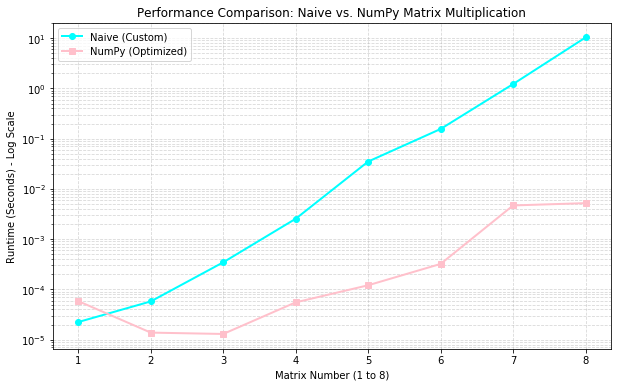

In [58]:
a = np.random.rand(3, 3)
a2 = np.random.rand(3, 3)

b = np.random.rand(6, 6)
b2 = np.random.rand(6, 6)

c = np.random.rand(12, 12)
c2= np.random.rand(12, 12)

d = np.random.rand(24, 24)
d2 = np.random.rand(24, 24)

e = np.random.rand(48, 48)
e2 = np.random.rand(48, 48)

f = np.random.rand(96, 96)
f2 = np.random.rand(96, 96)

g = np.random.rand(192, 192)
g2 = np.random.rand(192, 192)

h = np.random.rand(384, 384)
h2 = np.random.rand(384, 384)


# 1. Implement Custom Matrix Multiplier (Naive)
def naive_matrix_multiplication(A, B):
    n = len(A)
    # Initialize result matrix with zeros
    C = [[0.0 for _ in range(n)] for _ in range(n)]
    for i in range(n):
        for j in range(n):
            for k in range(n):
                C[i][j] += A[i][k] * B[k][j]
    return C


sizes = [3 * (2**i) for i in range(8)]
matrix_numbers = list(range(1, 9))

# Lists to store runtimes for the final plot
naive_durations = []
numpy_durations = []

print(f"{'Matrix #':<10} | {'Size (N)':<10} | {'Naive Time (s)':<18} | {'NumPy Time (s)':<18}")
print("-" * 65)

# 3. Time both methods across all 8 matrix pairs
for idx, n in enumerate(sizes):
    # Generate random matrices
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)
    
    # time naive 
    #converted A and B to lists to match typical naive function inputs
    A_list = A.tolist()
    B_list = B.tolist()
    
    start_naive = time.perf_counter()
    _ = naive_matrix_multiplication(A_list, B_list)
    t_naive = time.perf_counter() - start_naive
    naive_durations.append(t_naive)
    
    #numpy mult
    start_numpy = time.perf_counter()
    _ = A @ B  # matrix multiplication 
    t_numpy = time.perf_counter() - start_numpy
    numpy_durations.append(t_numpy)
    
    print(f"#{matrix_numbers[idx]:<8} | {n:<10} | {t_naive:<18.6f} | {t_numpy:<18.6f}") # asked to help with the sizing anf formatting results printed 

# Compare and plot runtimes (Matrix Number vs Runtime)
plt.figure(figsize=(10, 6))

# Plot Naive and NumPy data
plt.plot(matrix_numbers, naive_durations, 'o-', label='Naive (Custom)', color='cyan', linewidth=2)
plt.plot(matrix_numbers, numpy_durations, 's-', label='NumPy (Optimized)', color='pink', linewidth=2)

plt.yscale('log') #asked chat gpt to help scale 

plt.xlabel('Matrix Number (1 to 8)')
plt.ylabel('Runtime (Seconds) - Log Scale')
plt.title('Performance Comparison: Naive vs. NumPy Matrix Multiplication')
plt.xticks(matrix_numbers)
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend()

plt.show()